In [ ]:
using Pkg
Pkg.add("Plots")
Pkg.add("Measures")
Pkg.add("LaTeXStrings")
Pkg.add("DataFrames")
Pkg.add("DoubleFloats")
Pkg.add("CSV")
Pkg.add("GLMakie")

In [1]:
using Plots, Measures, LaTeXStrings
theme(:ggplot2)
default(guidefontsize=18, tickfontsize=10)
#gr(size = (950mm, 450mm)) # Sets the GR backend with a default size
default(size=(800mm, 450mm), left_margin = [10mm 0mm])

In [2]:
using DoubleFloats

#Energías del hidrógeno de Bohr
function EBohr(n::Int64)
            
            h = Double64(6.62607015E-34)
            c = Double64(299792458)
            eV = Double64(1.602177E-19)
            ħ = h/(2π)  #constante de Planck/2π
            e = Double64(1.602176634E-19)  #carga del electrón SI
            m = Double64(9.1093837015E-31) #masa del electrón en kg
            k = Double64(8.9875517873681764E9)	#constante de Coulomb
            E = Float64(-(1 / (n ^2)) * (k^2 * e^4 * m / ( 2 * ħ^2 ) )/eV)
    
    return E;
end

#radios de la órbita del electrón del hidrógeno de Bohr
function radiiBohr(n::Int64)
            h = Double64(6.62607015E-34)
            ħ = h/(2π)  #constante de Planck/2π
            e = Double64(1.602176634E-19)  #carga del electrón SI
            m = Double64(9.1093837015E-31) #masa del electrón en kg
            k = Double64(8.9875517873681764E9)	#constante de Coulomb
            return  Float64(((n .^2) .* ħ^2) ./ (m * k * e^2 ))
end

#Función para dibujar círculos

function circulo(h::Float64,k::Float64,r::Float64)
                θ = LinRange(0,2π,500)
                h .+ r*sin.(θ), k .+ r*cos.(θ)
end;

### Hasta ahora

Vimos que hay dos experimentos:

* El espectro de emisión de un cuerpo negro (es un espectro *continuo*)
* El efecto fotoeléctrico

Que necesitan de una interpretación particular de la radiación EM, en la cual se postula que la radiación EM se transporta como paquetes, llamados fotones:

  * Cada fotón tiene energía $$E = hf = \frac{hc}{\lambda}$$
  * Cada fotón tiene una cantidad de movimiento (momento lineal, momentum) $$p = \frac{E}{c} = \frac{hf}{c} = \frac{h}{\lambda}$$
 Cada fotón viaja a $c \sim 3 \times 10^{8} ms^{-1}$,  y cumple que $\lambda f = c$.

#### Extractado de:
**Física para Ciencias e Ingeniería con Física Moderna**. Vol. 2, 7ma ed. Serway y Jewett. Cap 42.1 -> 42.3.
## Espectros atómicos de los gases

Vamos a pensar en un experimento que le dio luces de colores a todo el mundo:

<img src="./grafdat/Ecoco.webp" alt="Alternative text" width="600"/>


#### Espectros atómicos de los gases

<img src="./grafdat/Efluo.png" alt="Alternative text" width="500"/>

Cuando hay una descarga eléctrica fuerte, los gases (a baja presión) emiten luz, teniendo un ***espectro de emisión*** que no es continuo, sino que consta de ***líneas discretas***.

En este efecto se basó la iluminación de buena parte de nuestros lugares de trabajo (que parecían lúgubres por la luz ***blanca*** *).

* Ojo que eso implica **fluorescencia**.


### Espectros atómicos de los gases:

El espectro (la luz que sale), no es continua como en un cuerpo negro, sino que es:
* Discreta
     * Formada por un conjunto de lineas.
     * Diferente para cada gas.



### Espectro atómico de los gases: emisión o absorción de luz.
Se muestra el espectro de emisión (absorción) del hidrógeno $H$, el mercurio $Hg$ y el neón $Ne$.

<img src="./grafdat/Eea.png" alt="Alternative text" width="900"/>


#### Espectros atómicos de los gases:
Balmer (modificado por Rydberg), cosiguió una fórmula sencilla que entregaba las líneas de emisión visibles del hidrógeno:

$$\frac{1}{\lambda_n} = R_H \Big( \frac{1}{2^2} - \frac{1}{n^2}\Big) \quad , \quad n = 3,4,5,...$$
con $R_H = 1.0967758.341\times 10^{7} \; m^{-1}$.

Las líneas medidas fueron: $\lambda_{H_\alpha} =656.3\; nm$, $\lambda_{H_\,\beta} =\,486.1\; nm$ , $\lambda_{H_\,\gamma} = 434.1 \; nm$,  $\lambda_{H_\delta} = 410.2 \; nm$.

* Calculando $\lambda_n$ para n = 3,4,5,6 la fórmular de Balmer - Rydberg:

In [7]:
using DoubleFloats
h = Double64(6.62607015E-34)
ħ = h / (2π)
m = Double64(9.1093837015E-31) #masa del electrón en kg
c = Double64(299792458)
eV = Double64(1.602177E-19)
RH = Double64(10967758.341)
n = [3,4,5,6]
print(round.(Float64.( 1 ./ (RH .* (1/4 .- 1 ./ n .^ 2))) , sigdigits = 4))

[6.565e-7, 4.863e-7, 4.342e-7, 4.103e-7]

In [6]:
h = Double64(6.62607015E-34)
            c = Double64(299792458)
            eV = Double64(1.602177E-19)
            ħ = h/(2π)  #constante de Planck/2π
            e = Double64(1.602176634E-19)  #carga del electrón SI
            m = Double64(9.1093837015E-31) #masa del electrón en kg
            k = Double64(8.9875517873681764E9)	#constante de Coulomb

k^2*e^4*m/ (4π * ħ^3 * c)

1.09737315561239526938031311650369287e+07

No existe base teórica para esta ecuación...son simplemente empíricas. Existen , además, series de Paschen, de Lyman y otro par de expresiones mencionadas en el libro.

# Los primeros modelos del átomo

* Época de Newton (circa 1700), los átomos fueron considerados **esferas rígidas e indestructibles**. Esto estuvo apoyado luego en la descripción termodinámica de los gases.

  <img src="./grafdat/Eesferas.png" alt="Alternative text" width="500"/>


* J.J. Thomson (circa 1897) descubre el electrón (carga negativa), y luego publica que el átomo (carga total = 0, neutro) es una mezcla de una carga positiva dispersa incrustada con electrones: Nace lo que se conoce como el modelo de budín (carga positiva dispersa) con pasas (electrones negativos).

<img src="./grafdat/Epasas.jpg" alt="Alternative text" width="700"/>

  

* Rutherford (1911): Dispara partículas $\alpha$ ($\mathbf{He^{2+}}$) hacia una lámina de oro. Las partículas son deflectadas en muchas direcciones $\Longrightarrow$ la carga positiva del átomo está concentrada en un lugar muy pequeño, mientras que los electrones dan vueltas a una distancia considerable.

|Experimento| Modelo átomo|
|:---:|:---:|
|<img src="./grafdat/Eeruth.png" alt="Alternative text" height="500"/>|<img src="./grafdat/Emr.png" alt="Alternative text" height="500"/>|


### Modelo de Rutherford

En este modelo, los electrones no están insertos en el núcleo (budín con pasas), sino que están girando alrededor. Este giro impide que la fuerza electrostática los haga caer al núcleo.

<img src="./grafdat/Emr.png" alt="Alternative text" width="400"/>

### Modelo de Rutherford - un gran problema

El problema de este modelo es lo que predice la teoría del ElectroMagnetismo (EM): las partículas cargadas que oscilan a una frecuencia $f$ emiten radiación de frec. $f$, perdiendo energía. Esto haría que los electrones pierdan energía y eventualmente colapsen con la carga positiva.

<img src="./grafdat/Emrp.png" alt="Alternative text" width="400"/>

# El modelo de Bohr del átomo de hidrógeno

#### El Modelo de Bohr del átomo de hidrógeno
Bohr (1913) presenta un ***modelo*** de átomo, con algunos postulados (**) que no se pueden justificar del todo.

1.  El electrón se mueve en órbitas circulares alrededor del protón bajo la influencia
de fuerza eléctrica de atracción: la partícula cargada positivamente en el centro (muy *masiva*) y el electrón orbitando alrededor.

1.  Sólo ciertas órbitas del electrón son estables. Cuando está en alguno de estos estados estacionarios, como los llamaba Bohr, el electrón no emite energía en forma de radiación.

1.   La radiación es emitida por el átomo cuando el electrón hace una transición de
una órbita inicial más energética a una órbita de menor energía.

$$E_i - E_f = hf$$

4.  Las órbitas permitidas tienen un ***momento angular cuantizado***:
$$L = m_e \;v\; r = n \frac{h}{2\pi} = n \hbar  \;\;^{(*)} \quad \quad n = 1,2,3,...$$

*A $\hbar = \frac{h}{2 \pi}$ se le dice "hache cortada o h barra"

***
** Para lectores curiosos, estos postulados no son los que usó Bohr. En Bohr (1913, p. 4) "On the Constitution of Atoms and Molecules", Bohr cita a Planck y la cuantización de la energía en lugar de como lo presenta el libro de Serway (y casi todos los libros de texto), la cuantización del momento angular. Puede buscarse el artículo para consultaen Sci Hub.
***

#### Modelo de Bohr del átomo de hidrógeno

|||
|:---:|:---:|
|<img src="./grafdat/Ebohr.png" alt="Alternative text" width="250"/>| Fuerza de Coulomb igual a $m \,a_c\;$: $$F = -k\frac{q_1q_2}{r^2} = \frac{k e^2}{r^2} = m\, a_c = m \frac{v^2}{r}$$ </b>$$v^2 = \frac{k\, e^2}{r m}$$|

De la última ecuación recordamos que, según el postulado (4) de Bohr, el momento angular $L$ está cuantizado (da saltos discretos en unidades de $\hbar$:

$$L = mvr = n\hbar \quad n = 1,2,3,...$$

Entonces vemos que el radio $r$ al cual ortbita el electrón está cuantizado también: $$L^2 = m^2v^2r^2 = n^2\hbar^2 \Longrightarrow r^2 = \frac{n^2 \; \hbar^2}{m^2 \; v^2}$$
Reemplazando $v^2$ en la expresión anterior, obtenemos la expresión ***cuantizada*** para $r$:
$$\Longrightarrow \boxed{r_n = \frac{n^2 \; \hbar^2}{m\, k\, e^2}}$$

In [67]:
using Plots, LaTeXStrings
theme(:ggplot2)
default(guidefontsize=18, tickfontsize=10)

n = [1,2,3,4]
rn = radiiBohr.(n) /1E-12

gradii = plot(size = (600,600),aspect_ratio = 1,xlabel = L"$10^{-12} \; m = \; fm \;=\; 1000\; nm$",
title = "Radios de órbita del hidrógeno del modelo de Bohr.")
j = Int64(1);

for i ∈ rn
    plot!(circulo.(0.0,0.0,i), color = palette(:default)[j],label = string("r = ", round(i, sigdigits = 3), " fm"), linewidth = 2.5);
    annotate!(0, i +50, text(string("n = ", j), color = palette(:default)[j], :center, 12));
    j = j+1;
end 

In [74]:
j = Int64(1);

grvsn = plot(title = "Radios en función de n",  ylabel = L"$r\; (fm = 10^{-12}m)$", xlabel = "n");
plot!(grvsn,1:0.1:4, (10^12) * radiiBohr(1) * (1:0.1:4) .^2,linewidth = 2, style = :dash, color = :black, label = "")
for i ∈ rn
    scatter!(grvsn, [j], [i], color = palette(:default)[j], markersize = 10, label = "")
    j = j + 1;
    
end;


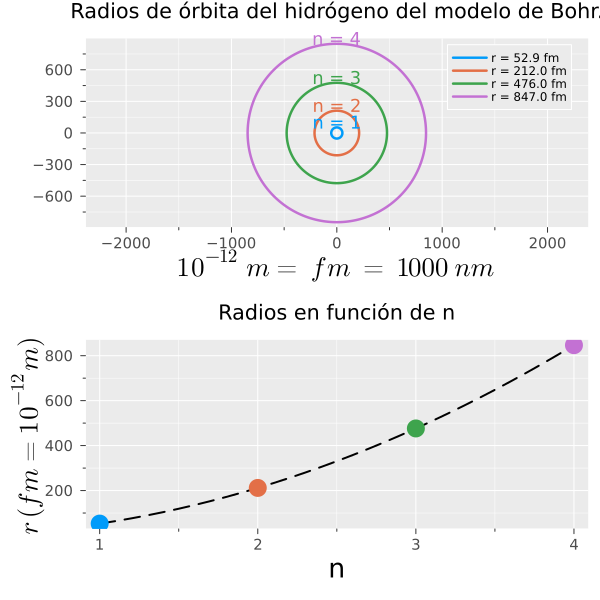

In [96]:
plot(gradii, grvsn, layout = (2, 1), size = (750,600))

* Los radios aumentan con el cuadrado de n.

### Modelo de Bohr y el radio del átomo de hidrógeno
Poniendo $n =1$ en la ecuación de los radios, tenemos que el radio más pequeños según el modelo es:
$$\boxed{r_n = \frac{n^2\hbar^2}{m\, k\, e^2}}$$

Lo cual, nos da, para $n = 1$, $r_n = a_0 = \hbar^2 \,/\, mke^2 \sim 0.0529 \; nm$

Muy cerca de lo que se especulaba en la época...y el primer gran logro de este modelo.

Obvio, la árbita del electrón se hace más y más grande...para $n \to \infty \;, \quad r\to \infty$, lo cual no quiere decir otra cosa que el radio crece sin límites 

## Energías en el modelo de Bohr

La energía cinética del electrón en movimiento circular uniforme es:
$$K = \frac{1}{2}mv^2 = \frac{1}{2}\frac{ke^2}{r}$$

La energía *potencial eléctrica* del electrón es:
$$U = k\frac{q_1q_2}{r} = -\frac{ke^2}{r}$$

La energía total queda: $$E = K + U = - \frac{ke^2}{2r}$$

## Energías en el modelo de Bohr

$$E = K + U = - \frac{ke^2}{2r}$$
* Acá notamos que $E < 0$ para cualquier $r$, es decir la energía total del electrón siempre es negativa (este electrón está *confinado*). No quiero agragar muchos detalles, pero esto pasa por cómo escribimos la energía potencial (el cero de potencial eléctrico de una carga está en $r\to\infty$).

* El cero de la energía total se da cuando $r \to \infty$, es decir, esto es la energía de ionización, cuánto cuesta ***arrancar*** el electrón para ***separarlo*** del protón.

Si tomamos la cuantización del radio $r = r_n = a_0 n^2$, la energía $E$ queda también cuantizada:
$$
E = -\frac{1}{n^2} \frac{k^2 \, e^4 \, m}{2 \hbar^2} =  -\frac{1}{n^2}\frac{ke^2}{2a_0} \quad n = 1,2,3,.... 
$$

* A medida que aumenta $n$, la energía del sistema se va acercando a $0$.

In [82]:
n = Int64[1,2,3,4]
E = EBohr.(n);

In [83]:

# Create the plot
gr = plot(size=(800, 500), legend=false);

# Plot each line
x_start = 1  # x-coordinate for the left end of lines
x_end = 2    # x-coordinate for the right end of lines

for i in eachindex(n)
    # Draw a vertical line from heighte le digamos 120.000 pesos por noche y que se queden las dos noches 0 to height E[i]
    plot!([x_start, x_end], [E[i], E[i]], 
          linewidth=4,
          color=:blue,
          alpha=0.7,
          label="")
    
    # Add n as label above each line
    annotate!((x_end) + 0.1, E[i] + 0.1, 
              text(string(round(E[i], sigdigits = 3), " eV"), :black, :center, 10))

    annotate!((x_start) - 0.1, E[i] + 0.1, 
              text(string("n = ",n[i]), :black, :center, 10))
end

#values for n -> infinity E = 0
plot!([x_start, x_end], [0, 0], 
          linewidth=4,
          color=:blue,
          alpha=0.7,
          label="")
    
    # Add n as label above each line
    annotate!((x_end) + 0.1, 0 + 0.1, 
              text(string(L"\to 0 eV"), :black, :center, 15))

    annotate!((x_start) - 0.1, 0 + 0.1, 
              text(string(L"$n \to \infty$"), :black, :center, 15))


# Formatting
plot!(xlims=(0.75, 2.25), ylims=(minimum(E), maximum(E) + 1));
plot!(xlabel="Line index", ylabel="n", title= L"Niveles de energía del modelo de Bohr para $H_2$", subtitle = "A");
plot!(xticks=([1.5], ["Lines"]), yticks = n );
plot!(axis=false, grid=false, framestyle=:none);  # Complete removal

### Energías en el átomo de Bohr y energía de ionización
$$
E = -\frac{1}{n^2} \frac{k^2 \, e^4 \, m}{2 \hbar^2} =  -\frac{1}{n^2}\frac{ke^2}{2a_0} \quad n = 1,2,3,... \quad ó \quad E \simeq -\frac{13.6 \;eV}{n^2}
$$

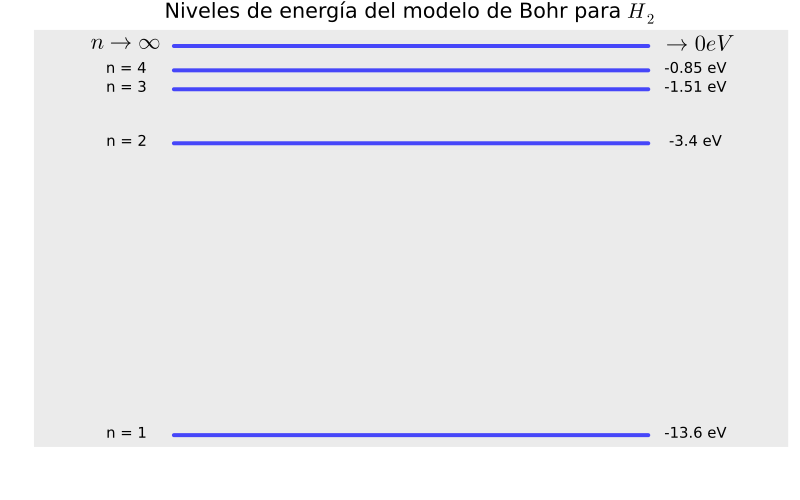

In [84]:
display(gr)

* A medida que $n \to \infty \; , \; E_n \to 0$
* También la diferencia de energía entre niveles consecutivos $E_n - E_{n-1} \to 0$ a medida que $n \to \infty$.
* La energía del nivel $n = 1$ es $E_1 \sim -\, 13.606 \; eV$, que es la energía de ionización del hidrógeno medida por otros medios. Este es el segundo logro del modelo de Bohr (mencionado en el propio artículo de 1913).

## Energía del modelo de Bohr para el hidrógeno y espectros discretos.
 El postulado (3) de Bohr dice que el electrón cambia de una órbita estable a otra de manera instantánea, absorbiendo o emitiendo un fotón de frecuencia $f$:

$$
f = \frac{\Big| E_f - E_i \Big|}{h} 
$$

* **Absorción**: El sistema absorve un fotón de frecuencia $f$, con lo que $E_f - E_i > 0$.

* **Emisión**: El sistema emite un fotón de frecuencia $f$, con lo que $E_f - E_i < 0$.

***
**Ejemplo** Si un átomo de hidrógeno pasa del nivel $E_2$ a $E_3$, ¿cuál es la longitud de onda del fotón absorbido?

Solución: Sabemos que la energía del nivel correspondiente a $n = 2$ es:

$$
E_2 = -\frac{1}{n^2} \frac{k^2 \, e^4 \, m}{2 \hbar^2} = -\frac{1}{2^2} \frac{k^2 \, e^4 \, m}{2 \hbar^2} =  -3.40\, eV
$$

Mientras que, $E_3 = -1.51$. Para saltar de $E_2$ a $E_3$, el átomo absorbió: $E_3 - E_2 \sim 1.89 \, eV$. Esto corresponde a un fotón de frecuencia $f = |(E_3 - E_2)|/h \sim 656 \, nm$ (ver serie de Balmer-Rydberg).

In [106]:
print(string("λ = ", round(c / ((E[3] - E[2]) * eV / h) * 1E9, sigdigits = 3), " nm")) ##en nm

λ = 656.0 nm

***
**Problema**
Un átomo de hidrógeno, que está en su estado base, es ionizado (se separa el electrón del protón). ¿Cuál es la frecuencia del fotón emitido? ¿y su longitud de onda?
***

In [95]:
print(string("f = ", round(13.606*eV/h, sigdigits = 5), " Hz\n")) #frecuencia
print(string("λ = ", round(c/(13.606*eV/h)*1E9, sigdigits = 5), " nm  ")) #lambda
print("Este fotón es UV")

f = 3.2899e15 Hz
λ = 91.125 nm  Este fotón es UV

***
***
### Éxitos del modelo de Bohr.
* Explica el por qué los espectros de emisión y absorción son discretos, a partir de la discretización del momento angular (energía en realidad).
* Le pega a todas las series conocidas de emisión/absorción del $H_2$
***
***

### Problemas del modelo de Bohr
* No puede explicar por qué hay órbitas estables en las cuales una partícula cargada no emite radiación EM.
* Si bien le pega a las líneas discretas:
        * Medidas posteriores más precisas, muestran que algunas líneas podían separarse en varias líneas adicionales.
        * La aplicación de campos magnéticos fuertes separaba ciertas líneas en tres líneas.
  * La imposibilidad de explicar lo anterior, termina en el colapso del modelo de Bohr y reemplazo por lo que hoy se conoce como "***Mecánica Cuántica***", quedando reservado para la radiación de Planck, el efecto fotoeléctrico de Einstein y el modelo de Bohr la denominación de teoría cuántica antigua. 

***
***
***
***